# Monte Carlo: insesgadez de MCO

**Sabemos que los estimadores de MCO son insesgados. ¿Podemos verlo mediante simulación?**

En el notebook anterior repetimos muchas veces el experimento de lanzar una moneda y observamos cómo se comportaba el estimador $\hat p$.

Ahora haremos exactamente lo mismo con una regresión lineal simple. En cada repetición generaremos una nueva muestra, estimaremos el modelo y guardaremos los valores de $b_1$, $b_2$ y $s^2$.


[Descargar este notebook (.ipynb)](https://github.com/amosino/mtx--courses/raw/refs/heads/main/MTX1/notebooks/04--montecarlo_mco.ipynb)

## Fijamos la semilla

`set.seed()` permite reproducir exactamente la misma secuencia de números pseudoaleatorios y, por tanto, obtener los mismos resultados al volver a ejecutar la simulación.


In [1]:
set.seed(123)


## Definimos los parámetros verdaderos

En cada muestra tendremos `n` observaciones y repetiremos el experimento `R` veces.

Los valores verdaderos del modelo son

$$
\beta_1=0.2,\qquad
\beta_2=2,\qquad
\sigma^2=4.
$$


In [2]:
n <- 20        # No. de observaciones
R <- 1000      # No. de repeticiones

beta_1 <- 0.2  # Valor verdadero de beta_1
beta_2 <- 2    # Valor verdadero de beta_2
sigma2 <- 4    # Valor verdadero de sigma^2


## Construimos la parte sistemática del modelo

Mantendremos fijos los valores de $x$ en todas las repeticiones:

$$
x_i=1,2,\ldots,n.
$$

Con ellos construimos la parte sistemática de

$$
y_i=\beta_1+\beta_2x_i+u_i.
$$

Lo que cambiará de una muestra a otra será el término de error $u_i$.


In [3]:
x <- 1:n
y_sist <- beta_1 + beta_2 * x


## Preparamos el almacenamiento

En cada repetición obtendremos nuevas estimaciones de $\beta_1$, $\beta_2$ y $\sigma^2$.

Los vectores `b1`, `b2` y `s2` guardarán esas realizaciones:

$$
b_{1,1},\ldots,b_{1,R},\qquad
b_{2,1},\ldots,b_{2,R},\qquad
s_1^2,\ldots,s_R^2.
$$


In [4]:
b1 <- numeric(R)
b2 <- numeric(R)
s2 <- numeric(R)


## Repetimos el experimento

El ciclo `for` representa el muestreo repetido.

En cada repetición:

1. generamos un nuevo conjunto de errores $u_i$;
2. construimos una nueva muestra de $y$;
3. estimamos la regresión por MCO;
4. guardamos $b_1$, $b_2$ y $s^2$.

La lógica es la misma que en el experimento de la moneda: una nueva muestra produce una nueva estimación.


In [5]:
for (i in 1:R) {

  # Generamos una nueva muestra
  u <- rnorm(n, mean = 0, sd = sqrt(sigma2))
  y <- y_sist + u

  # Estimamos el modelo
  mod <- lm(y ~ x)

  # Guardamos las estimaciones
  b1[i] <- coef(mod)[1]
  b2[i] <- coef(mod)[2]
  s2[i] <- summary(mod)$sigma^2
}


## Aproximamos los valores esperados

Los promedios Monte Carlo aproximan los valores esperados de los estimadores:

$$
\frac{1}{R}\sum_{r=1}^{R} b_{1r}\approx E(b_1),\qquad
\frac{1}{R}\sum_{r=1}^{R} b_{2r}\approx E(b_2),
$$

y de manera análoga para $s^2$.

Si los estimadores son insesgados, estos promedios deberían estar cerca de los parámetros verdaderos.


In [6]:
b1_mean <- mean(b1)
b2_mean <- mean(b2)
s2_mean <- mean(s2)

sesgo_b1 <- b1_mean - beta_1
sesgo_b2 <- b2_mean - beta_2
sesgo_s2 <- s2_mean - sigma2


## Comparamos con los valores verdaderos

La tabla resume el experimento: para cada parámetro comparamos su valor verdadero con el promedio de las estimaciones obtenidas en las `R` repeticiones.


In [7]:
resultados <- data.frame(
  Parametro = c("beta_1", "beta_2", "sigma2"),
  Verdadero = c(beta_1, beta_2, sigma2),
  Promedio_MC = c(b1_mean, b2_mean, s2_mean),
  Sesgo_MC = c(sesgo_b1, sesgo_b2, sesgo_s2)
)

resultados


Parametro,Verdadero,Promedio_MC,Sesgo_MC
<chr>,<dbl>,<dbl>,<dbl>
beta_1,0.2,0.1776007,-0.0223993296
beta_2,2.0,2.0009643,0.0009642952
sigma2,4.0,4.0161782,0.0161781566


## Distribución de $b_1$

El histograma muestra cómo cambia $b_1$ entre las distintas muestras. La línea vertical marca el valor verdadero $\beta_1$.


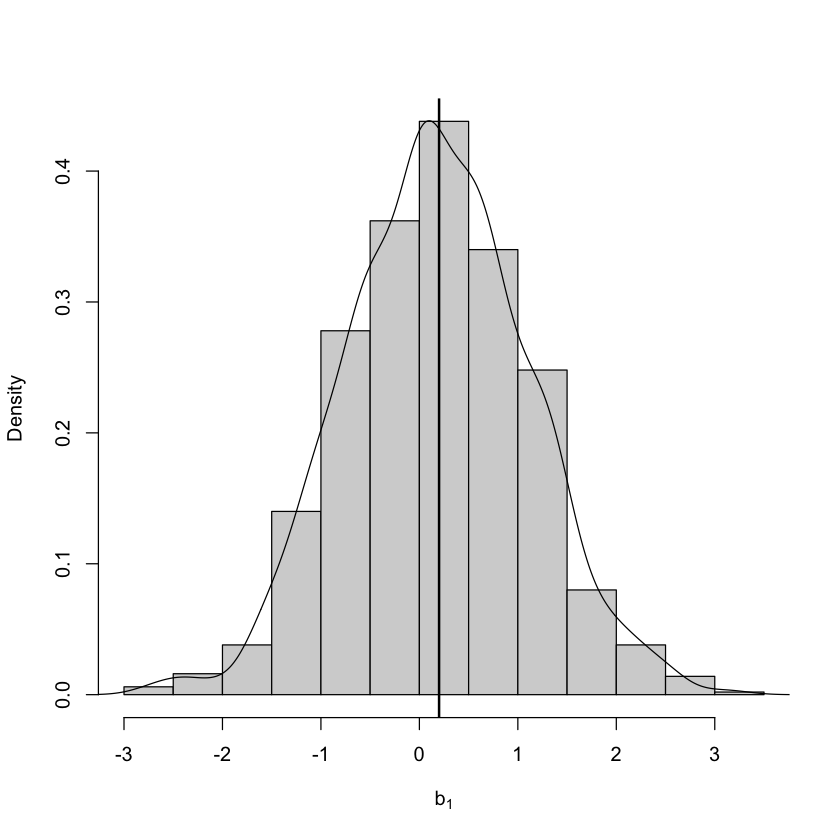

In [8]:
hist(b1, freq = FALSE,
     xlab = expression(b[1]),
     main = "")

lines(density(b1))
abline(v = beta_1, lwd = 2)


## Distribución de $b_2$

Ahora observamos la distribución de $b_2$. Nuevamente, la línea vertical indica el valor verdadero $\beta_2$.


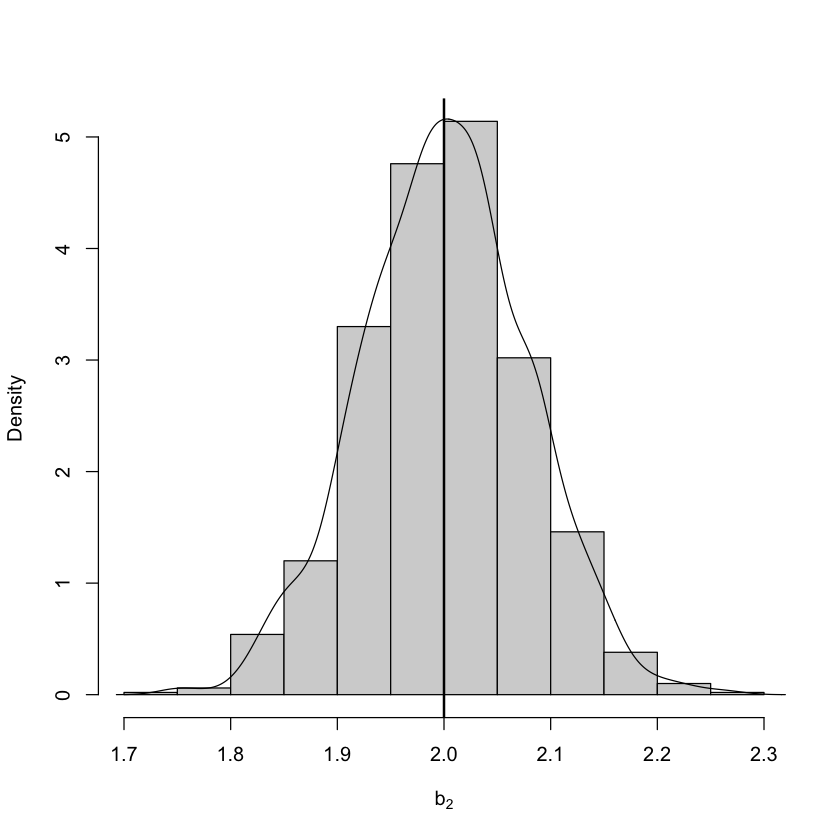

In [9]:
hist(b2, freq = FALSE,
     xlab = expression(b[2]),
     main = "")

lines(density(b2))
abline(v = beta_2, lwd = 2)


## Distribución de $s^2$

Finalmente observamos el comportamiento de $s^2$ frente al valor verdadero de $\sigma^2$.


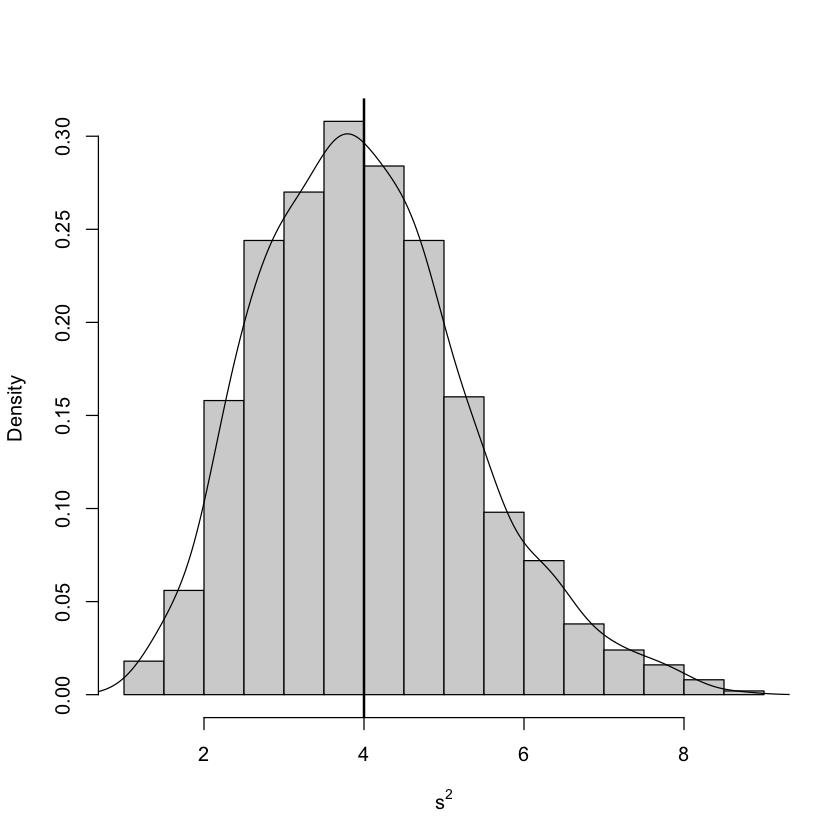

In [10]:
hist(s2, freq = FALSE,
     xlab = expression(s^2),
     main = "")

lines(density(s2))
abline(v = sigma2, lwd = 2)


## Interpretación

Cada muestra produce estimaciones diferentes de $\beta_1$, $\beta_2$ y $\sigma^2$. Esa variación es consecuencia del muestreo.

Sin embargo, al repetir muchas veces el experimento, los promedios Monte Carlo de $b_1$, $b_2$ y $s^2$ se aproximan a los parámetros verdaderos.

La simulación ilustra así la idea de insesgadez bajo muestreo repetido. La misma estrategia puede utilizarse para estudiar otras propiedades de los estimadores.
